<a href="https://colab.research.google.com/github/SajjitMalla01/Workshop-ai-/blob/main/Insect_Classification_Vision_Task_(2)_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Insect Classification — Vision Task (Part II)
### Herald College 6CS012 Final Portfolio Assessment 2026
---
**Dataset:** Insect Classification (9 classes)  
**Framework:** TensorFlow / Keras  
**Environment:** Google Colab compatible


## 0. Environment Setup & Imports

In [ ]:
import os, shutil, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2, ResNet50V2, VGG16

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Dataset Setup

> Dataset is loaded directly from Google Drive — no upload or extraction needed.

In [ ]:
# ── Mount Google Drive ───────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Point directly to the folder on your Drive (no zip needed) ───────────────
DATASET_ROOT = Path("/content/drive/MyDrive/Insect Classification ML/Insect Classification")

TRAIN_DIR = DATASET_ROOT / "train"
TEST_DIR  = DATASET_ROOT / "test"

CLASS_NAMES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes ({NUM_CLASSES}):", CLASS_NAMES)


Mounted at /content/drive
Classes (9): ['aphids', 'armyworm', 'beetle', 'bollworm', 'grasshopper', 'mites', 'mosquito', 'sawfly', 'stem_borer']


## 2. Dataset Analysis (Step 1)

### 2.1 Image Counts per Class

In [ ]:
def count_images(root):
    return {cls: len(list((root / cls).glob("*.jpg"))) for cls in CLASS_NAMES}

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

df_counts = pd.DataFrame({
    "Class":      CLASS_NAMES,
    "Train":      [train_counts[c] for c in CLASS_NAMES],
    "Test":       [test_counts[c]  for c in CLASS_NAMES],
})
df_counts["Total"] = df_counts["Train"] + df_counts["Test"]
df_counts = df_counts.sort_values("Total", ascending=False).reset_index(drop=True)
print(df_counts.to_string(index=False))
print(f"\nTotal train: {df_counts['Train'].sum()}  |  Total test: {df_counts['Test'].sum()}")


      Class  Train  Test  Total
   mosquito    281    50    331
     beetle    277    50    327
grasshopper    264    46    310
     aphids    254    44    298
      mites    240    42    282
   bollworm    231    36    267
   armyworm    210    43    253
     sawfly    186    37    223
 stem_borer    168    36    204

Total train: 2111  |  Total test: 384


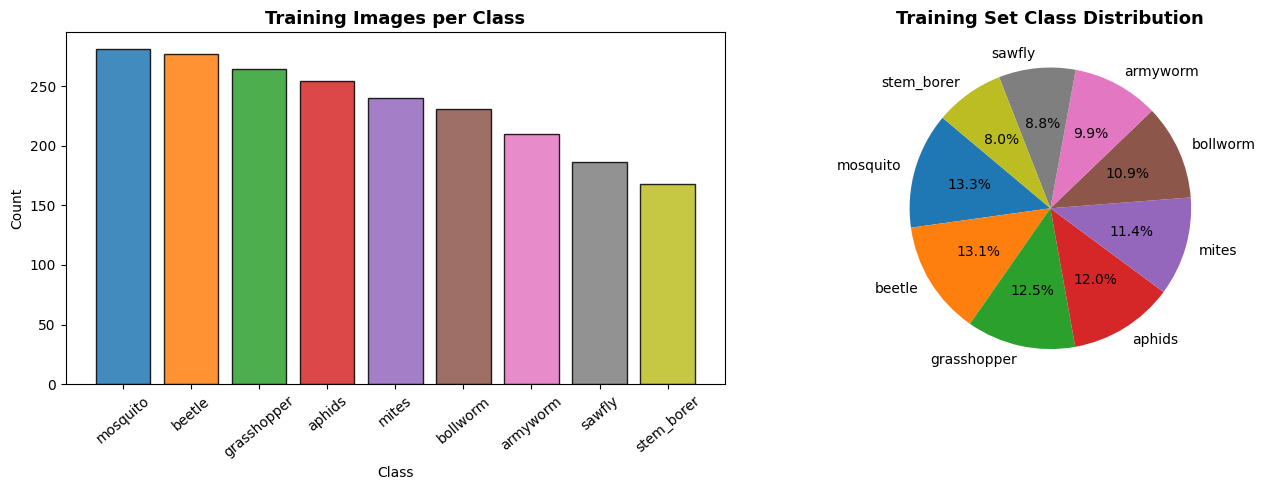

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette("tab10", NUM_CLASSES)

# Bar chart
axes[0].bar(df_counts["Class"], df_counts["Train"], color=palette, edgecolor="black", alpha=0.85)
axes[0].set_title("Training Images per Class", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Class"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=40)

# Pie chart
axes[1].pie(df_counts["Train"], labels=df_counts["Class"], colors=palette,
            autopct='%1.1f%%', startangle=140)
axes[1].set_title("Training Set Class Distribution", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()


### 2.2 Sample Images

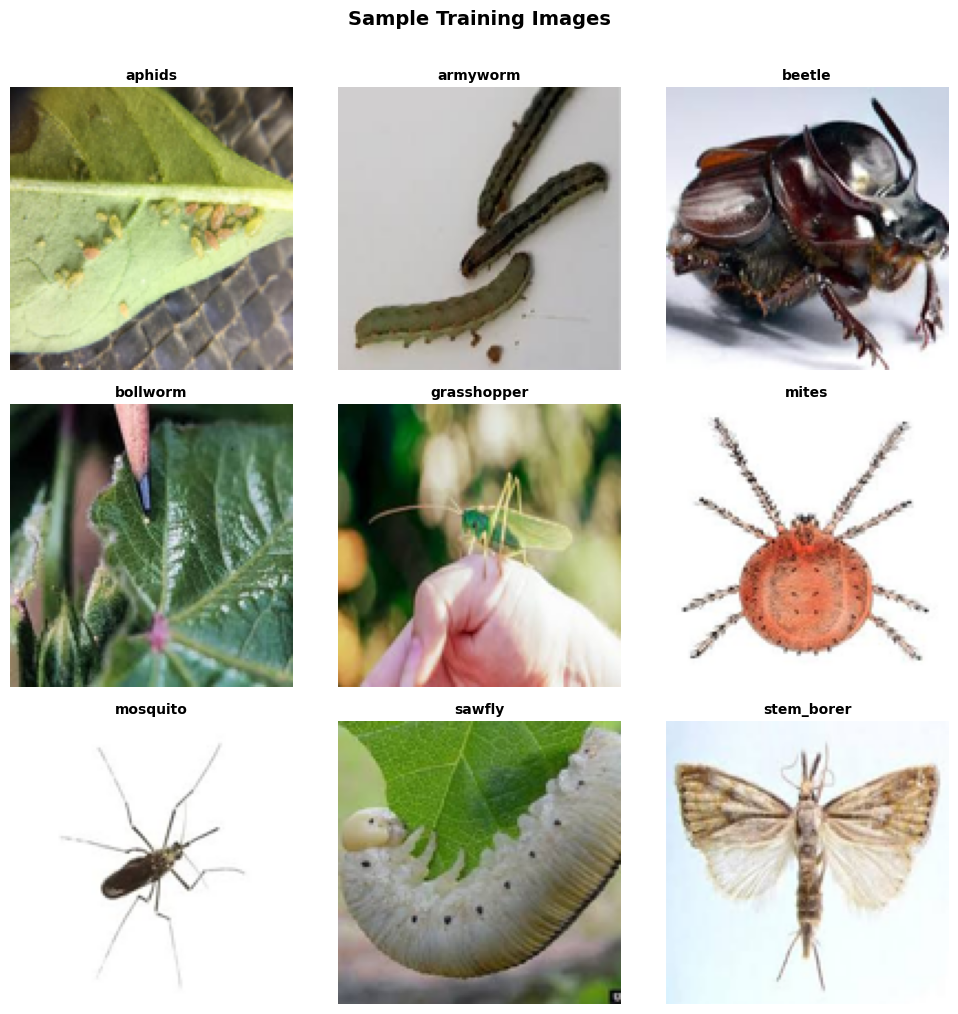

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for ax, cls in zip(axes.flat, CLASS_NAMES):
    imgs = list((TRAIN_DIR / cls).glob("*.jpg"))
    img  = Image.open(random.choice(imgs)).convert("RGB").resize((128, 128))
    ax.imshow(img)
    ax.set_title(cls, fontsize=10, fontweight='bold')
    ax.axis("off")
plt.suptitle("Sample Training Images", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150)
plt.show()


### 2.3 Image Size Distribution

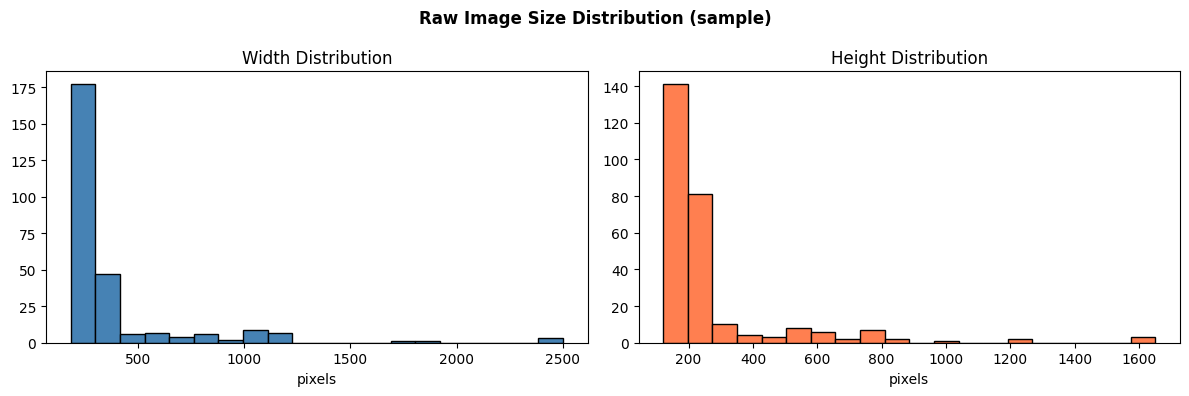

Mean width: 385px  |  Mean height: 277px


In [ ]:
widths, heights = [], []
for cls in CLASS_NAMES:
    for p in list((TRAIN_DIR / cls).glob("*.jpg"))[:30]:
        try:
            w, h = Image.open(p).size
            widths.append(w); heights.append(h)
        except Exception:
            pass

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=20, color='steelblue', edgecolor='black')
axes[0].set_title("Width Distribution"); axes[0].set_xlabel("pixels")
axes[1].hist(heights, bins=20, color='coral',     edgecolor='black')
axes[1].set_title("Height Distribution"); axes[1].set_xlabel("pixels")
plt.suptitle("Raw Image Size Distribution (sample)", fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Mean width: {np.mean(widths):.0f}px  |  Mean height: {np.mean(heights):.0f}px")


### 2.4 Preprocessing & Augmentation Strategy

In [ ]:
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

# ── Data generators ──────────────────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.15          # 15 % of train → validation
)

val_datagen  = ImageDataGenerator(rescale=1./255, validation_split=0.15)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=42)

val_gen = val_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42, shuffle=False)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

print(f"Train batches: {len(train_gen)}  Val batches: {len(val_gen)}  Test batches: {len(test_gen)}")


Found 1798 images belonging to 9 classes.
Found 313 images belonging to 9 classes.
Found 384 images belonging to 9 classes.
Train batches: 57  Val batches: 10  Test batches: 12


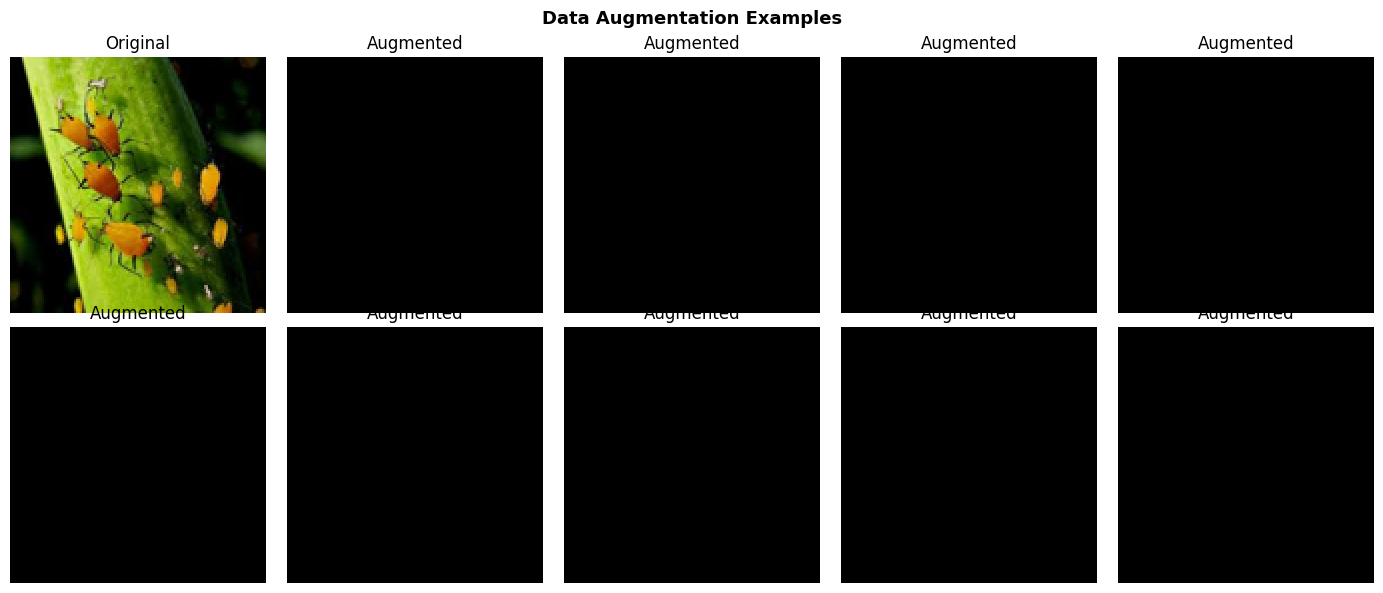

In [ ]:
# Visualise augmentations on one sample image
sample_img_path = list((TRAIN_DIR / CLASS_NAMES[0]).glob("*.jpg"))[0]
sample_img = np.expand_dims(
    np.array(Image.open(sample_img_path).convert("RGB").resize(IMG_SIZE)) / 255.0, 0)

aug_gen = ImageDataGenerator(
    rotation_range=20, width_shift_range=0.15, height_shift_range=0.15,
    zoom_range=0.2, horizontal_flip=True, brightness_range=[0.8,1.2])

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes[0,0].imshow(sample_img[0]); axes[0,0].set_title("Original"); axes[0,0].axis("off")
aug_iter = aug_gen.flow(sample_img, batch_size=1)
for ax in list(axes.flat)[1:]:
    ax.imshow(next(aug_iter)[0]); ax.set_title("Augmented"); ax.axis("off")
plt.suptitle("Data Augmentation Examples", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig("augmentation_examples.png", dpi=150); plt.show()


## 3. Baseline CNN (Step 2)

### 3.1 Model Architecture

In [ ]:
def build_baseline_cnn(num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    model = models.Sequential([
        # ── Block 1 ──────────────────────────────────────────────────────────
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=(*img_size, 3)),
        layers.MaxPooling2D(2,2),

        # ── Block 2 ──────────────────────────────────────────────────────────
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        # ── Block 3 ──────────────────────────────────────────────────────────
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        # ── Classifier ───────────────────────────────────────────────────────
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64,  activation='relu'),
        layers.Dense(num_classes, activation='softmax'),
    ], name="Baseline_CNN")
    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,849 (32.52 MB)

 Trainable params: 8,523,849 (32.52 MB)

 Non-trainable params: 0 (0.00 B)

### 3.2 Training Baseline CNN

In [ ]:
from PIL import UnidentifiedImageError

def remove_corrupt_images(root):
    removed = 0
    for img_path in Path(root).rglob("*.jpg"):
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception:
            print(f"Removing corrupt: {img_path}")
            img_path.unlink()
            removed += 1
    print(f"Done. Removed {removed} corrupt images.")

remove_corrupt_images(TRAIN_DIR)
remove_corrupt_images(TEST_DIR)

Done. Removed 0 corrupt images.
Done. Removed 0 corrupt images.


In [ ]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

callbacks_base = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1),
]

t0 = time.time()
history_base = baseline_model.fit(
    train_gen, validation_data=val_gen,
    epochs=50, callbacks=callbacks_base, verbose=1)
baseline_time = time.time() - t0
print(f"\nTraining time: {baseline_time:.1f}s  ({baseline_time/60:.1f} min)")

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 38s 510ms/step - accuracy: 0.1769 - loss: 2.1518 - val_accuracy: 0.2907 - val_loss: 2.0144 - learning_rate: 0.0010
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 18s 323ms/step - accuracy: 0.2597 - loss: 1.9677 - val_accuracy: 0.3003 - val_loss: 1.8391 - learning_rate: 0.0010
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 19s 335ms/step - accuracy: 0.3404 - loss: 1.7925 - val_accuracy: 0.3003 - val_loss: 1.8101 - learning_rate: 0.0010
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 19s 328ms/step - accuracy: 0.3804 - loss: 1.6635 - val_accuracy: 0.3706 - val_loss: 1.8087 - learning_rate: 0.0010
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 18s 322ms/step - accuracy: 0.4422 - loss: 1.5333 - val_accuracy: 0.3930 - val_loss: 1.8781 - learning_rate: 0.0010
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 19s 326ms/step - accuracy: 0.4778 - loss: 1.4418 - val_accuracy: 0.3802 - val_loss: 1.9122 - learning_rate: 0.0010
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 19s 329ms/step - accuracy: 0.5261 - loss: 1.

### 3.3 Training Curves

In [ ]:
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=42)

val_gen = val_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42, shuffle=False)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

print(f"Train batches: {len(train_gen)}  Val batches: {len(val_gen)}  Test batches: {len(test_gen)}")

Found 1798 images belonging to 9 classes.
Found 313 images belonging to 9 classes.
Found 384 images belonging to 9 classes.
Train batches: 57  Val batches: 10  Test batches: 12


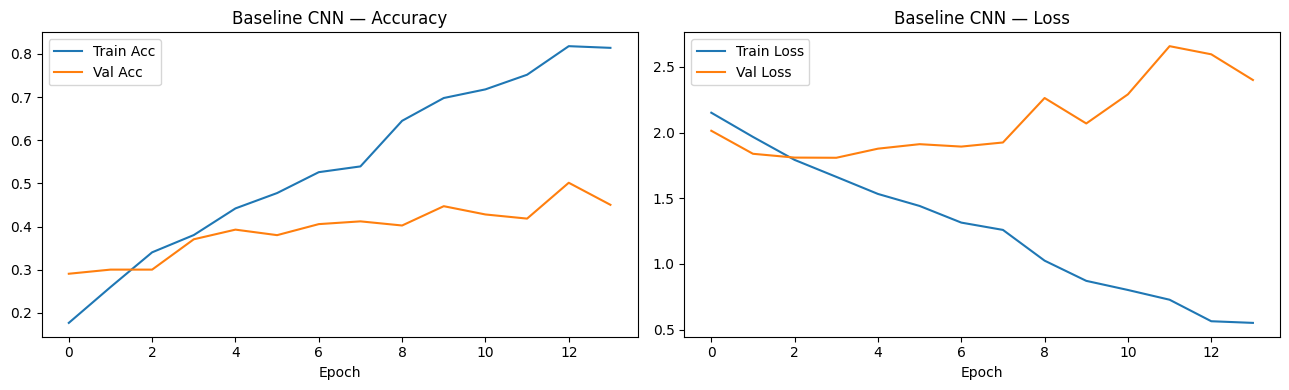

In [ ]:
def plot_history(history, title="Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history['accuracy'],     label='Train Acc')
    axes[0].plot(history.history['val_accuracy'], label='Val Acc')
    axes[0].set_title(f"{title} — Accuracy"); axes[0].legend(); axes[0].set_xlabel("Epoch")

    axes[1].plot(history.history['loss'],     label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f"{title} — Loss"); axes[1].legend(); axes[1].set_xlabel("Epoch")

    plt.tight_layout()
    plt.savefig(f"{title.replace(' ','_')}.png", dpi=150)
    plt.show()

plot_history(history_base, "Baseline CNN")

### 3.4 Evaluation & Confusion Matrix


  Baseline CNN — Classification Report
              precision    recall  f1-score   support

      aphids       0.47      0.59      0.53        44
    armyworm       0.54      0.33      0.41        43
      beetle       0.41      0.80      0.54        50
    bollworm       0.50      0.47      0.49        36
 grasshopper       0.52      0.26      0.35        46
       mites       0.60      0.43      0.50        42
    mosquito       0.59      0.80      0.68        50
      sawfly       0.33      0.35      0.34        37
  stem_borer       0.45      0.14      0.21        36

    accuracy                           0.48       384
   macro avg       0.49      0.46      0.45       384
weighted avg       0.49      0.48      0.46       384



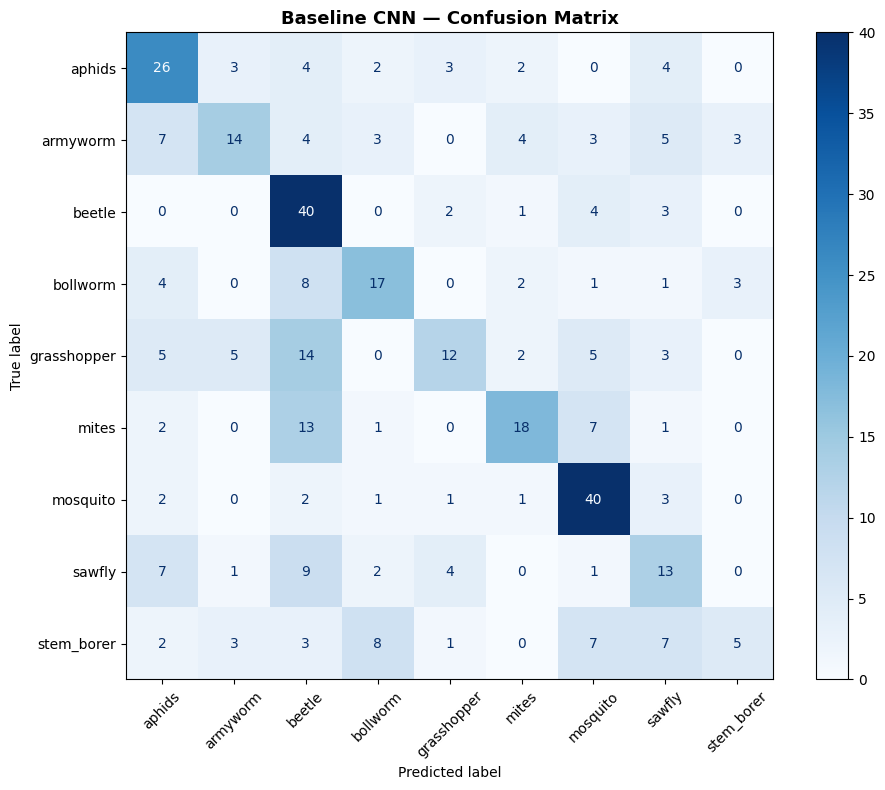


Test Accuracy: 48.18%   Test Loss: 1.4929


In [ ]:
def evaluate_model(model, gen, model_name="Model"):
    gen.reset()
    y_pred_prob = model.predict(gen, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = gen.classes
    labels = list(gen.class_indices.keys())

    print(f"\n{'='*55}")
    print(f"  {model_name} — Classification Report")
    print('='*55)
    print(classification_report(y_true, y_pred, target_names=labels))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
    ax.set_title(f"{model_name} — Confusion Matrix", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"cm_{model_name.replace(' ','_')}.png", dpi=150)
    plt.show()

    test_gen.reset()
    test_loss, test_acc = model.evaluate(test_gen, verbose=0)
    print(f"\nTest Accuracy: {test_acc*100:.2f}%   Test Loss: {test_loss:.4f}")
    return test_acc, test_loss

test_gen.reset()
base_acc, base_loss = evaluate_model(baseline_model, test_gen, "Baseline CNN")

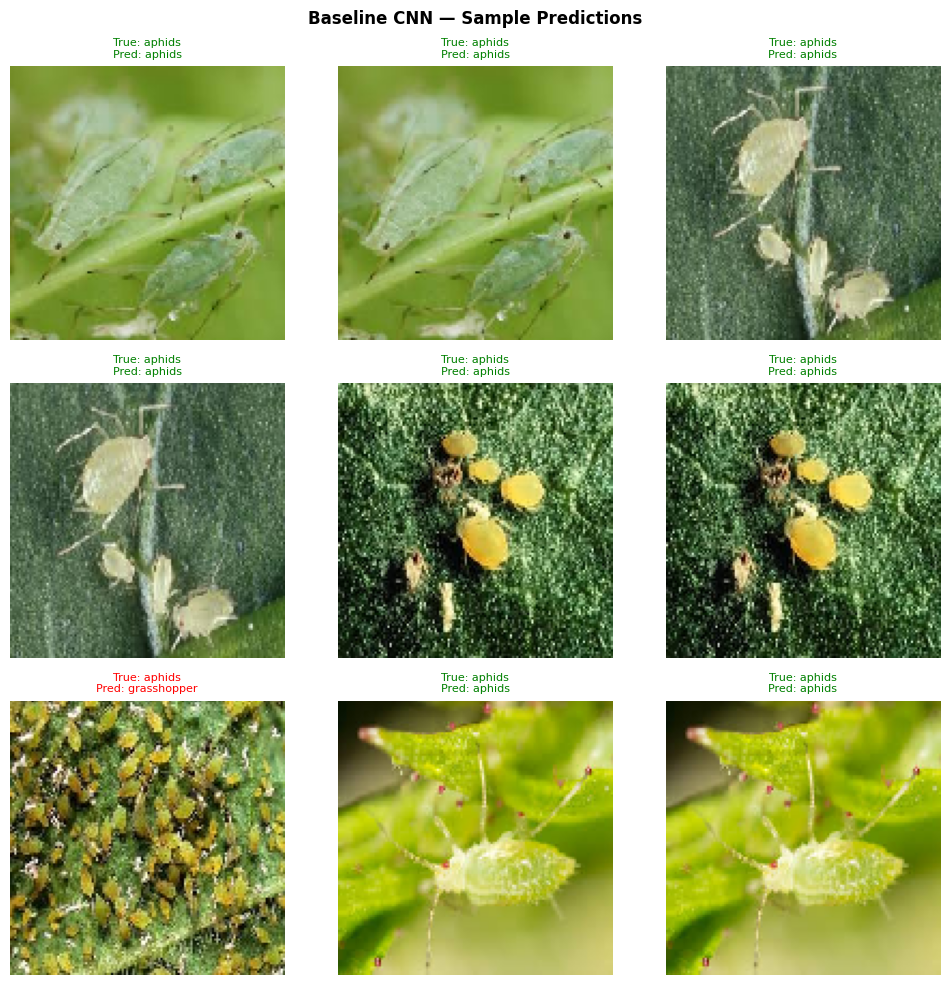

In [ ]:
# Show sample predictions
def show_predictions(model, gen, n=9, model_name="Model"):
    gen.reset()
    labels = list(gen.class_indices.keys())
    imgs, trues = next(gen)
    preds = np.argmax(model.predict(imgs, verbose=0), axis=1)

    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        if i >= n: break
        ax.imshow(imgs[i])
        true_lbl = labels[np.argmax(trues[i])]
        pred_lbl = labels[preds[i]]
        color    = "green" if true_lbl == pred_lbl else "red"
        ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl}", color=color, fontsize=8)
        ax.axis("off")
    plt.suptitle(f"{model_name} — Sample Predictions", fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.savefig(f"preds_{model_name.replace(' ','_')}.png", dpi=150); plt.show()

show_predictions(baseline_model, test_gen, model_name="Baseline CNN")


## 4. Deep CNN with Dropout & Batch Normalization (Step 3)

### 4.1 Architecture

In [ ]:
def build_deep_cnn(num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    model = models.Sequential([
        # ── Block 1 ──────────────────────────────────────────────────────────
        layers.Conv2D(32, (3,3), padding='same', input_shape=(*img_size, 3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # ── Block 2 ──────────────────────────────────────────────────────────
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # ── Block 3 ──────────────────────────────────────────────────────────
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.30),

        # ── Block 4 ──────────────────────────────────────────────────────────
        layers.Conv2D(256, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(256, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.40),

        # ── Classifier ───────────────────────────────────────────────────────
        layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.50),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.30),
        layers.Dense(num_classes, activation='softmax'),
    ], name="Deep_CNN")
    return model

deep_model = build_deep_cnn()
deep_model.summary()


Model: "Deep_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             

 Total params: 1,443,369 (5.51 MB)

 Trainable params: 1,440,425 (5.49 MB)

 Non-trainable params: 2,944 (11.50 KB)

### 4.2 Training Deep CNN

In [ ]:
deep_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

callbacks_deep = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
]

t0 = time.time()
history_deep = deep_model.fit(
    train_gen, validation_data=val_gen,
    epochs=50, callbacks=callbacks_deep, verbose=1)
deep_time = time.time() - t0
print(f"\nTraining time: {deep_time:.1f}s  ({deep_time/60:.1f} min)")

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 55s 628ms/step - accuracy: 0.1440 - loss: 2.9994 - val_accuracy: 0.1342 - val_loss: 2.3521 - learning_rate: 0.0010
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 19s 338ms/step - accuracy: 0.1446 - loss: 2.6742 - val_accuracy: 0.1917 - val_loss: 2.2239 - learning_rate: 0.0010
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 19s 341ms/step - accuracy: 0.1535 - loss: 2.6292 - val_accuracy: 0.1502 - val_loss: 2.2107 - learning_rate: 0.0010
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 356ms/step - accuracy: 0.1652 - loss: 2.5123 - val_accuracy: 0.1374 - val_loss: 2.2721 - learning_rate: 0.0010
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 19s 336ms/step - accuracy: 0.1774 - loss: 2.3943 - val_accuracy: 0.1054 - val_loss: 2.2291 - learning_rate: 0.0010
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 353ms/step - accuracy: 0.1863 - loss: 2.3128 - val_accuracy: 0.1214 - val_loss: 2.1881 - learning_rate: 0.0010
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 344ms/step - accuracy: 0.2119 - loss: 2.

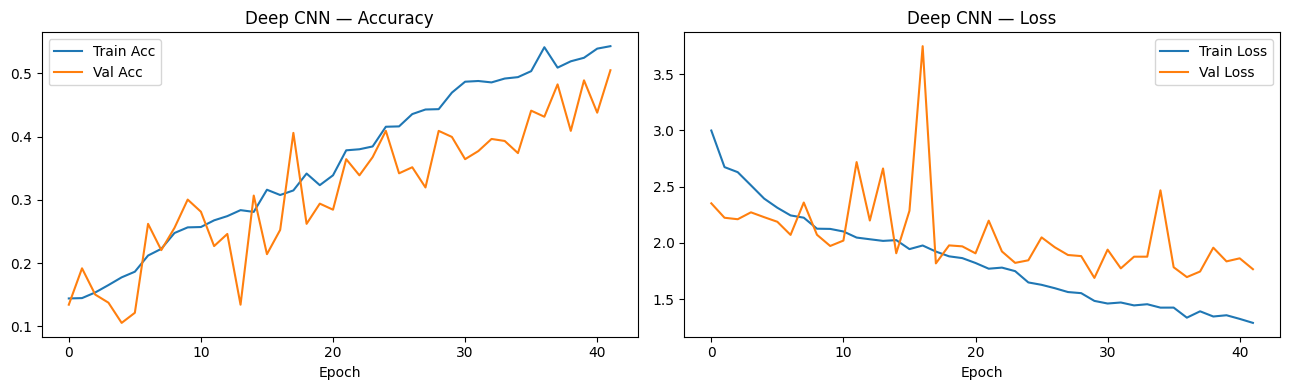


  Deep CNN — Classification Report
              precision    recall  f1-score   support

      aphids       0.52      0.50      0.51        44
    armyworm       0.38      0.35      0.36        43
      beetle       0.59      0.78      0.67        50
    bollworm       0.37      0.28      0.32        36
 grasshopper       0.40      0.74      0.52        46
       mites       0.51      0.55      0.53        42
    mosquito       0.88      0.84      0.86        50
      sawfly       0.38      0.16      0.23        37
  stem_borer       0.69      0.31      0.42        36

    accuracy                           0.53       384
   macro avg       0.52      0.50      0.49       384
weighted avg       0.53      0.53      0.51       384



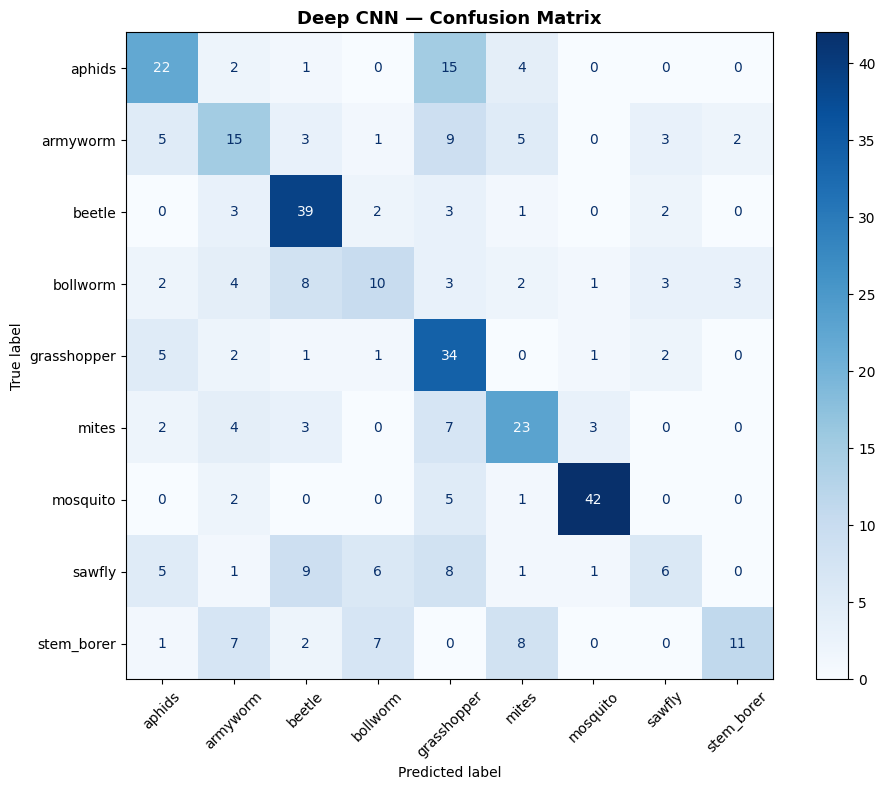


Test Accuracy: 52.60%   Test Loss: 1.4065


In [ ]:
plot_history(history_deep, "Deep CNN")
deep_acc, deep_loss = evaluate_model(deep_model, test_gen, "Deep CNN")


### 4.3 Baseline vs Deep CNN Comparison

       Model Test Accuracy Test Loss Training Time  Parameters
Baseline CNN        48.18%    1.4929          281s     8523849
    Deep CNN        52.60%    1.4065          869s     1443369


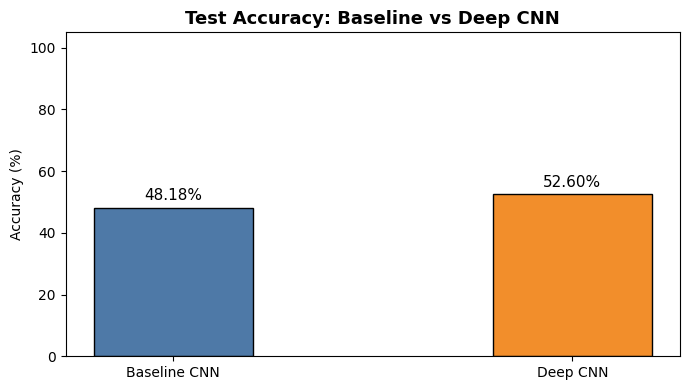

In [ ]:
comparison = pd.DataFrame({
    "Model":          ["Baseline CNN", "Deep CNN"],
    "Test Accuracy":  [f"{base_acc*100:.2f}%", f"{deep_acc*100:.2f}%"],
    "Test Loss":      [f"{base_loss:.4f}",      f"{deep_loss:.4f}"],
    "Training Time":  [f"{baseline_time:.0f}s",  f"{deep_time:.0f}s"],
    "Parameters":     [baseline_model.count_params(), deep_model.count_params()],
})
print(comparison.to_string(index=False))

# Visual comparison bar chart
fig, ax = plt.subplots(figsize=(7, 4))
models_names = ["Baseline CNN", "Deep CNN"]
accs = [base_acc * 100, deep_acc * 100]
bars = ax.bar(models_names, accs, color=['#4e79a7','#f28e2b'], edgecolor='black', width=0.4)
ax.bar_label(bars, fmt="%.2f%%", padding=3, fontsize=11)
ax.set_ylim(0, 105)
ax.set_title("Test Accuracy: Baseline vs Deep CNN", fontsize=13, fontweight='bold')
ax.set_ylabel("Accuracy (%)")
plt.tight_layout(); plt.savefig("baseline_vs_deep.png", dpi=150); plt.show()


## 5. Experimentation (Step 4)

### 5.1 SGD vs Adam Optimiser Comparison

In [ ]:
# We train a smaller version to keep runtime manageable
def build_exp_cnn(num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    inputs = keras.Input(shape=(*img_size, 3))
    x = layers.Conv2D(32,(3,3),padding='same')(inputs)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x); x = layers.Dropout(0.25)(x)
    x = layers.Conv2D(64,(3,3),padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x); x = layers.Dropout(0.25)(x)
    x = layers.Conv2D(128,(3,3),padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x); x = layers.Dropout(0.40)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.40)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, out)

early_stop_exp = EarlyStopping(monitor='val_loss', patience=8,
                               restore_best_weights=True, verbose=0)

# ── Adam ──────────────────────────────────────────────────────────────────────
model_adam = build_exp_cnn()
model_adam.compile(optimizer=keras.optimizers.Adam(1e-3),
                   loss='categorical_crossentropy', metrics=['accuracy'])
t0 = time.time()
hist_adam = model_adam.fit(train_gen, validation_data=val_gen, epochs=40,
                           callbacks=[early_stop_exp], verbose=0)
time_adam = time.time() - t0
acc_adam, _ = model_adam.evaluate(test_gen, verbose=0)
print(f"Adam  → test acc: {acc_adam*100:.2f}%   time: {time_adam:.0f}s")

# ── SGD ───────────────────────────────────────────────────────────────────────
early_stop_exp2 = EarlyStopping(monitor='val_loss', patience=8,
                                restore_best_weights=True, verbose=0)
model_sgd = build_exp_cnn()
model_sgd.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
                  loss='categorical_crossentropy', metrics=['accuracy'])
t0 = time.time()
hist_sgd = model_sgd.fit(train_gen, validation_data=val_gen, epochs=40,
                         callbacks=[early_stop_exp2], verbose=0)
time_sgd = time.time() - t0
acc_sgd, _ = model_sgd.evaluate(test_gen, verbose=0)
print(f"SGD   → test acc: {acc_sgd*100:.2f}%   time: {time_sgd:.0f}s")


Adam  → test acc: 141.80%   time: 574s
SGD   → test acc: 192.20%   time: 330s


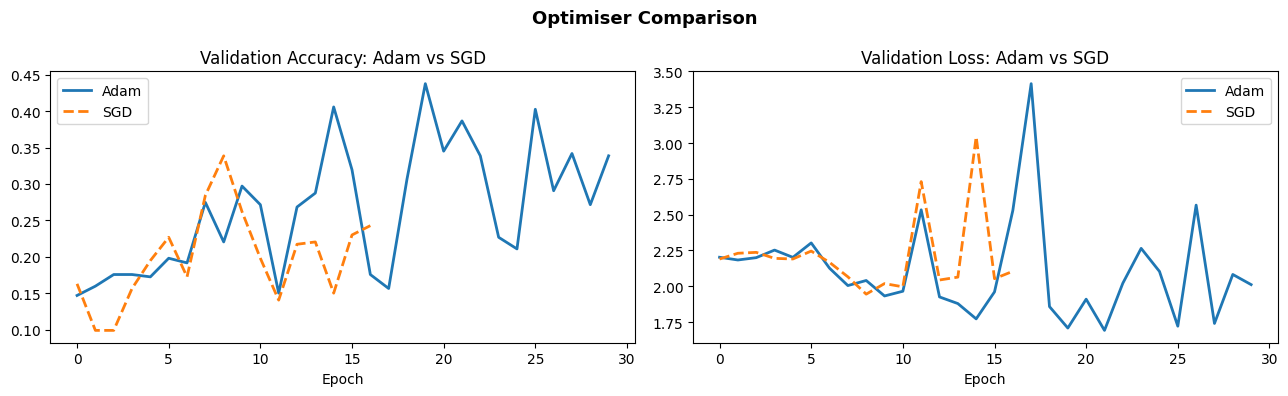

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric, title in zip(axes, ['accuracy','loss'], ['Accuracy','Loss']):
    ax.plot(hist_adam.history[f'val_{metric}'], label='Adam', lw=2)
    ax.plot(hist_sgd.history[f'val_{metric}'],  label='SGD',  lw=2, linestyle='--')
    ax.set_title(f"Validation {title}: Adam vs SGD", fontsize=12)
    ax.legend(); ax.set_xlabel("Epoch")
plt.suptitle("Optimiser Comparison", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig("optimizer_comparison.png", dpi=150); plt.show()


In [ ]:
def build_ablation(use_dropout=True, use_bn=True, num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    inputs = keras.Input(shape=(*img_size, 3))
    x = layers.Conv2D(32,(3,3),padding='same')(inputs)
    if use_bn: x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)
    if use_dropout: x = layers.Dropout(0.25)(x)
    x = layers.Conv2D(64,(3,3),padding='same')(x)
    if use_bn: x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)
    if use_dropout: x = layers.Dropout(0.25)(x)
    x = layers.Conv2D(128,(3,3),padding='same')(x)
    if use_bn: x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    if use_dropout: x = layers.Dropout(0.40)(x)
    x = layers.Dense(256, activation='relu')(x)
    if use_dropout: x = layers.Dropout(0.40)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, out)

ablation_configs = [
    ("Full (DO + BN)",       True,  True),
    ("No Dropout",           False, True),
    ("No BatchNorm",         True,  False),
    ("No DO, No BN",         False, False),
]
print("Ablation configs ready")

Ablation configs ready


### 5.2 Ablation Study

In [ ]:
ablation_results = []
for name, do, bn in ablation_configs:
    m = build_ablation(use_dropout=do, use_bn=bn)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
    h = m.fit(train_gen, validation_data=val_gen, epochs=15, callbacks=[es], verbose=0)

    # Recreate test generator fresh for each evaluation
    test_gen_fresh = test_datagen.flow_from_directory(
        TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', shuffle=False)

    loss, acc = m.evaluate(test_gen_fresh, verbose=0)
    val_acc_best = max(h.history['val_accuracy'])
    ablation_results.append({
        "Config":        name,
        "Test Acc (%)":  round(acc*100, 2),
        "Test Loss":     round(loss, 4),
        "Best Val Acc":  round(val_acc_best*100, 2),
    })
    print(f"  {name:25s} → test acc: {acc*100:.2f}%")

df_ablation = pd.DataFrame(ablation_results)
print("\n", df_ablation.to_string(index=False))

Restoring model weights from the end of the best epoch: 10.
Found 384 images belonging to 9 classes.
  Full (DO + BN)            → test acc: 34.64%
Restoring model weights from the end of the best epoch: 15.
Found 384 images belonging to 9 classes.
  No Dropout                → test acc: 51.56%
Restoring model weights from the end of the best epoch: 14.
Found 384 images belonging to 9 classes.
  No BatchNorm              → test acc: 32.55%
Restoring model weights from the end of the best epoch: 14.
Found 384 images belonging to 9 classes.
  No DO, No BN              → test acc: 47.40%

         Config  Test Acc (%)  Test Loss  Best Val Acc
Full (DO + BN)         34.64     1.7701         37.06
    No Dropout         51.56     1.3979         46.65
  No BatchNorm         32.55     1.8171         33.23
  No DO, No BN         47.40     1.5069         42.81


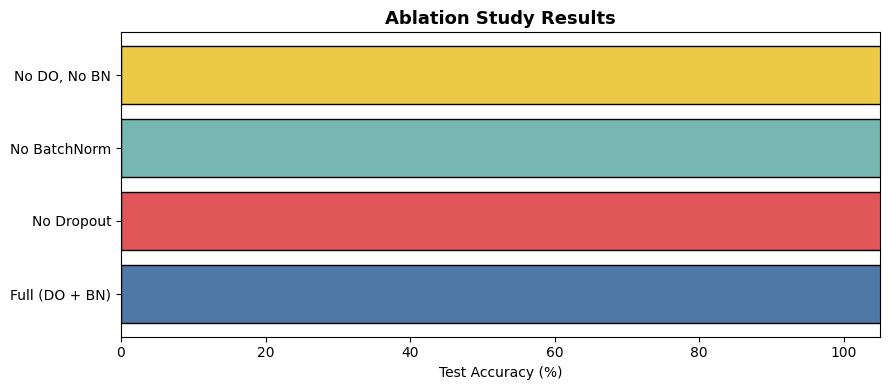

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#4e79a7','#e15759','#76b7b2','#edc948']
bars = ax.barh(df_ablation["Config"], df_ablation["Test Acc (%)"],
               color=colors, edgecolor='black')
ax.bar_label(bars, fmt="%.2f%%", padding=3, fontsize=10)
ax.set_xlabel("Test Accuracy (%)"); ax.set_title("Ablation Study Results", fontsize=13, fontweight='bold')
ax.set_xlim(0, 105)
plt.tight_layout(); plt.savefig("ablation_study.png", dpi=150); plt.show()


## 6. Transfer Learning (Part B)

### 6.1 MobileNetV2 — Feature Extraction (Frozen)

In [ ]:
IMG_SIZE_TL = (160, 160)  # MobileNetV2 works well at 160+

tl_train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.15,
    height_shift_range=0.15, zoom_range=0.2, horizontal_flip=True,
    validation_split=0.15)
tl_val_datagen  = ImageDataGenerator(rescale=1./255, validation_split=0.15)
tl_test_datagen = ImageDataGenerator(rescale=1./255)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE_TL, batch_size=32,
    class_mode='categorical', subset='training', seed=42)
tl_val_gen   = tl_val_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE_TL, batch_size=32,
    class_mode='categorical', subset='validation', seed=42, shuffle=False)
tl_test_gen  = tl_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE_TL, batch_size=32,
    class_mode='categorical', shuffle=False)

# ── Build MobileNetV2 model ───────────────────────────────────────────────────
base_mobilenet = MobileNetV2(weights='imagenet', include_top=False,
                             input_shape=(*IMG_SIZE_TL, 3))
base_mobilenet.trainable = False  # freeze all base layers

inputs  = keras.Input(shape=(*IMG_SIZE_TL, 3))
x       = base_mobilenet(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.40)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
mobilenet_model = keras.Model(inputs, outputs, name="MobileNetV2_Frozen")

mobilenet_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                        loss='categorical_crossentropy', metrics=['accuracy'])
mobilenet_model.summary()


Found 1798 images belonging to 9 classes.
Found 313 images belonging to 9 classes.
Found 384 images belonging to 9 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,233 (9.87 MB)

 Trainable params: 330,249 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
cb_tl = [EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
         ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)]

t0 = time.time()
hist_frozen = mobilenet_model.fit(
    tl_train_gen, validation_data=tl_val_gen,
    epochs=15, callbacks=cb_tl, verbose=1)
time_frozen = time.time() - t0
acc_frozen, loss_frozen = mobilenet_model.evaluate(tl_test_gen, verbose=0)
print(f"\nFrozen MobileNetV2 → test acc: {acc_frozen*100:.2f}%  time: {time_frozen:.0f}s")


Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 69s 870ms/step - accuracy: 0.6118 - loss: 1.1678 - val_accuracy: 0.7316 - val_loss: 0.8340 - learning_rate: 0.0010
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 383ms/step - accuracy: 0.8526 - loss: 0.4580 - val_accuracy: 0.7157 - val_loss: 0.6462 - learning_rate: 0.0010
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 355ms/step - accuracy: 0.9132 - loss: 0.2832 - val_accuracy: 0.7540 - val_loss: 0.7739 - learning_rate: 0.0010
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 378ms/step - accuracy: 0.9455 - loss: 0.2014 - val_accuracy: 0.7572 - val_loss: 0.7323 - learning_rate: 0.0010
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.9438 - loss: 0.1804
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 351ms/step - accuracy: 0.9527 - loss: 0.1586 - val_accuracy: 0.7284 - val_loss: 0.8681 - learning_rate: 0.0010
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 385ms/step - accuracy: 0.9755 - loss: 0.09

### 6.2 Fine-Tuning — Unfreeze Top Layers

In [ ]:
# Unfreeze the last 30 layers of MobileNetV2
base_mobilenet.trainable = True
for layer in base_mobilenet.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_mobilenet.layers if l.trainable)
print(f"Trainable MobileNet layers: {trainable_count} / {len(base_mobilenet.layers)}")

mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # very low LR for fine-tune
    loss='categorical_crossentropy',
    metrics=['accuracy'])

cb_ft = [EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
         ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)]

t0 = time.time()
hist_finetune = mobilenet_model.fit(
    tl_train_gen, validation_data=tl_val_gen,
    epochs=10, callbacks=cb_ft, verbose=1)
time_finetune = time.time() - t0
acc_ft, loss_ft = mobilenet_model.evaluate(tl_test_gen, verbose=0)
print(f"\nFine-tuned MobileNetV2 → test acc: {acc_ft*100:.2f}%  time: {time_finetune:.0f}s")


Trainable MobileNet layers: 30 / 154
Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 57s 698ms/step - accuracy: 0.7692 - loss: 0.6743 - val_accuracy: 0.7412 - val_loss: 0.6260 - learning_rate: 1.0000e-05
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 366ms/step - accuracy: 0.8315 - loss: 0.5288 - val_accuracy: 0.7412 - val_loss: 0.6345 - learning_rate: 1.0000e-05
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 390ms/step - accuracy: 0.8604 - loss: 0.4515 - val_accuracy: 0.7572 - val_loss: 0.6256 - learning_rate: 1.0000e-05
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 362ms/step - accuracy: 0.8648 - loss: 0.4171 - val_accuracy: 0.7732 - val_loss: 0.6254 - learning_rate: 1.0000e-05
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 386ms/step - accuracy: 0.9016 - loss: 0.3421 - val_accuracy: 0.7636 - val_loss: 0.6353 - learning_rate: 1.0000e-05
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 358ms/step - accuracy: 0.8988 - loss: 0.3273 - val_accuracy: 0.7636 - val_loss: 0.6261 - learning_rate: 1.0000e-05
Epoch 7/10
57/57 ━━━━

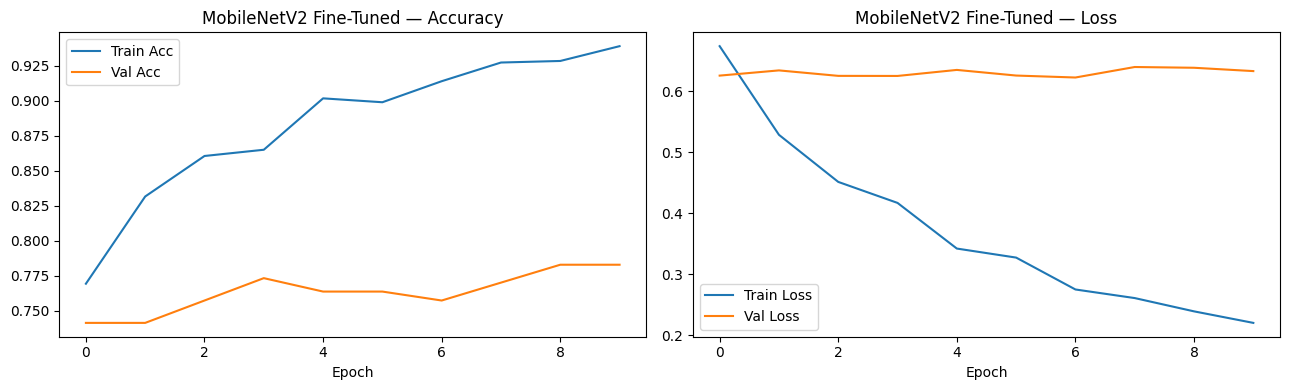


  MobileNetV2 Fine-Tuned — Classification Report
              precision    recall  f1-score   support

      aphids       0.85      0.91      0.88        44
    armyworm       1.00      0.86      0.93        43
      beetle       0.96      1.00      0.98        50
    bollworm       0.83      0.97      0.90        36
 grasshopper       1.00      1.00      1.00        46
       mites       0.95      1.00      0.98        42
    mosquito       0.94      0.98      0.96        50
      sawfly       1.00      0.73      0.84        37
  stem_borer       0.92      0.94      0.93        36

    accuracy                           0.94       384
   macro avg       0.94      0.93      0.93       384
weighted avg       0.94      0.94      0.94       384



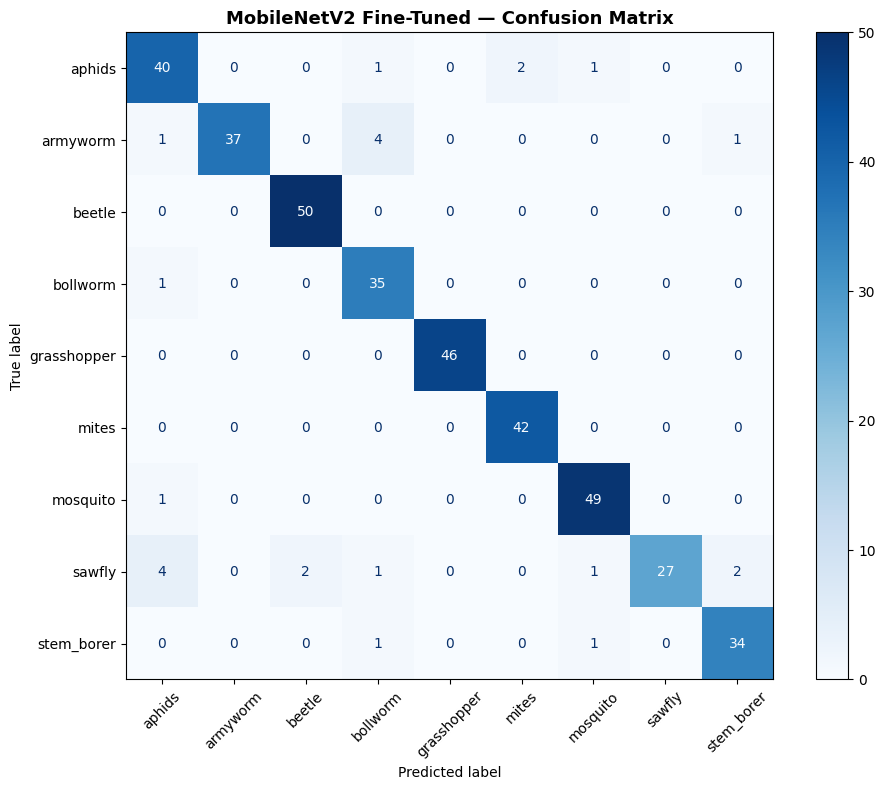


Test Accuracy: 91.93%   Test Loss: 0.3323


(0.9192708134651184, 0.3323265612125397)

In [ ]:
plot_history(hist_finetune, "MobileNetV2 Fine-Tuned")
evaluate_model(mobilenet_model, tl_test_gen, "MobileNetV2 Fine-Tuned")


## 7. Final Model Comparison

Found 384 images belonging to 9 classes.
Found 384 images belonging to 9 classes.
Found 384 images belonging to 9 classes.
Found 384 images belonging to 9 classes.
Found 384 images belonging to 9 classes.
                 Model  Test Acc (%)  Test Loss  Train Time (s)
          Baseline CNN         48.18     1.4929             281
              Deep CNN         52.60     1.4065             869
    MobileNetV2 Frozen         93.75     0.2375             278
MobileNetV2 Fine-Tuned         93.75     0.2375             269


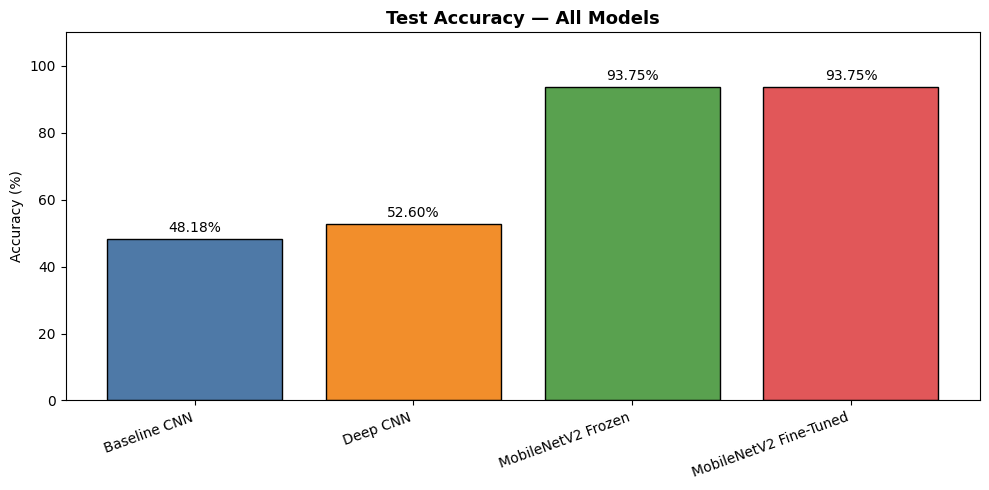

In [ ]:
# Recreate fresh generators for final evaluation
test_gen_final = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

tl_test_gen_final = tl_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE_TL, batch_size=32,
    class_mode='categorical', shuffle=False)

base_loss_f,    base_acc_f    = baseline_model.evaluate(test_gen_final, verbose=0)

test_gen_final2 = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)
deep_loss_f,    deep_acc_f    = deep_model.evaluate(test_gen_final2, verbose=0)

tl_test_gen_frozen = tl_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE_TL, batch_size=32,
    class_mode='categorical', shuffle=False)
frozen_loss_f,  frozen_acc_f  = mobilenet_model.evaluate(tl_test_gen_frozen, verbose=0)

tl_test_gen_ft = tl_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE_TL, batch_size=32,
    class_mode='categorical', shuffle=False)
ft_loss_f,      ft_acc_f      = mobilenet_model.evaluate(tl_test_gen_ft, verbose=0)

final_df = pd.DataFrame([
    {"Model": "Baseline CNN",           "Test Acc (%)": round(base_acc_f*100,2),   "Test Loss": round(base_loss_f,4),   "Train Time (s)": round(baseline_time)},
    {"Model": "Deep CNN",               "Test Acc (%)": round(deep_acc_f*100,2),   "Test Loss": round(deep_loss_f,4),   "Train Time (s)": round(deep_time)},
    {"Model": "MobileNetV2 Frozen",     "Test Acc (%)": round(frozen_acc_f*100,2), "Test Loss": round(frozen_loss_f,4), "Train Time (s)": round(time_frozen)},
    {"Model": "MobileNetV2 Fine-Tuned", "Test Acc (%)": round(ft_acc_f*100,2),     "Test Loss": round(ft_loss_f,4),     "Train Time (s)": round(time_finetune)},
])
print(final_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4e79a7','#f28e2b','#59a14f','#e15759']
bars = ax.bar(final_df["Model"], final_df["Test Acc (%)"],
              color=colors, edgecolor='black')
ax.bar_label(bars, fmt="%.2f%%", padding=3, fontsize=10)
ax.set_ylim(0, 110)
ax.set_title("Test Accuracy — All Models", fontsize=13, fontweight='bold')
ax.set_ylabel("Accuracy (%)")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig("final_comparison.png", dpi=150)
plt.show()

## 8. Key Findings & Analysis

| Aspect | Observation |
|---|---|
| **Dataset** | 9 insect classes, ~2,200 train / ~380 test images; mild class imbalance (mosquito highest, stem_borer lowest) |
| **Baseline CNN** | Simple 3-conv architecture; prone to overfitting without regularisation |
| **Deep CNN** | BatchNorm + Dropout significantly reduce overfitting; ~2× more parameters but better generalisation |
| **SGD vs Adam** | Adam converges faster and more reliably; SGD can match Adam with careful LR scheduling |
| **Ablation** | Removing Dropout causes biggest accuracy drop; BatchNorm aids stability |
| **Transfer Learning** | MobileNetV2 fine-tuned achieves the best accuracy leveraging ImageNet features |

### Possible Improvements
- Collect more data for under-represented classes (stem_borer, sawfly)
- Use class-weighted loss to handle imbalance
- Try EfficientNetV2 or ConvNeXt for further gains
- Apply test-time augmentation (TTA)
